# **FEATURE EXTRACTION**

## **LIBRARIES**

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import scipy.signal
import soundfile as sf
from tqdm import tqdm
from scipy.signal import butter, filtfilt, correlate
import scipy.stats
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from typing import Union, Tuple
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import f_classif, mutual_info_classif
import yaml
import re
from collections import Counter
from collections import defaultdict

Load parameters and other configuration values.

In [4]:
# Load audio processing constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

SAMPLING_RATE = config["audio_processing"]["sampling_rate"] # Resample the audio files with frequency 4 kHz, since wheezes and crackles are typically within frequency range 0–2 kHz
FRAME_LENGTH = config["audio_processing"]["frame_length"] # Use window size of 60 ms for each cycle
HOP_LENGTH = config["audio_processing"]["hop_length"] # Use 50% overlap
N_MFCC = config["audio_processing"]["n_mfcc"] # Extract the first 13 MFCCs
N_MELS = config["audio_processing"]["n_mels"] # Use 64 Mel Banks to extract the Log-Mel Spectrograms
F_HI = config["audio_processing"]["f_hi"] # Boundary frequency for VLTP is set to 2 kHz
TARGET_DURATION = config["audio_processing"]["target_duration"] # Fix the duration of each cycle to 8 s

FRAME_SIZE = int(FRAME_LENGTH*SAMPLING_RATE) # Calculate the amount of samples per frame
HOP_SIZE = int(HOP_LENGTH*SAMPLING_RATE) #  Calculate the amount of samples per hop

# Load basic paths from config.yaml
AUDIO_FOLDER = os.path.join(os.getcwd(), config["paths"]["audio_folder"])
RAW_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder"])
CLEANED_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["cleaned_cycle_folder"])
TRAINING_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["training_set_folder"])
TEST_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["test_set_folder"])

# Feature names 
FEATURE_NAMES = (
    [f"MFCC_{i}" for i in range(N_MFCC)] +
    ["Spectral Centroid", "Spectral Bandwidth", "Zero Crossing Rate", "RMS Energy",
     "Spectral Rolloff", "Spectral Flux", "Spectral Flatness", "LogMel_Mean", "LogMel_Std"]
)

# Number of features used
N_FEATURES = len(FEATURE_NAMES) 

# Number of frames
N_FRAMES=267

In [5]:
# Load training and test sets
train_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "raw_training_set.csv"))
final_train_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "training_set.csv"))
augmented_labels_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "augmented_training_set.csv"))
test_df = pd.read_csv(os.path.join(TEST_SET_FOLDER, "test_set.csv"))

For both training and testing set we extract **MFCCs, Log-Mel statistic, temporal and spectral features** from the final respiratory cycles and create a **flattened feature vector of size (frames x features, 1)** for each one of them. Also the **frame length of each cycle is set to 60 ms** with an **overlap of 50%**. These values perform well in terms of low frequency respiratory sounds. For the STFT that is calculated on the features we apply **Hann Window** to smoothen the data leakage. In total **267 frames are used for each respiratory cycle**. Also, the features are extracted across the whole .wav file so that no significant information is omitted.

In [9]:
from utils.audio_preprocessing import classify, extract_acoustic_features

augmented_labels_dict = dict(zip(augmented_labels_df["file"], augmented_labels_df["class"]))

sets = {
    "training": final_train_df,
    "test": test_df
}

# Extract the features from both training and testing set
for split_name, df_subset in sets.items():
    features = []
    labels = []
    filenames = []
    cycles = []

    for fname in tqdm(df_subset["file"], desc=f"Extracting features for {split_name} set"):
        path = os.path.join(CLEANED_CYCLE_FOLDER, fname)
        if not os.path.exists(path):
            print(f"Missing file: {fname}")
            continue

        y, sr = librosa.load(path, sr=SAMPLING_RATE)

        # Extract frame-level features for each respiratory cycle
        feats = extract_acoustic_features(
            y, sr,
            frame_size=FRAME_SIZE,
            hop_size=HOP_SIZE,
            n_mfcc=N_MFCC,
            n_mels=N_MELS
        )

        # Flatten the features for the entire cycle
        feats_flattened = feats.flatten() # (frames × features, )

        # Find label that corresponds to this cycle
        if fname.startswith("AUG_"):
            label = augmented_labels_dict.get(fname)
            if label is None:
                print(f"Warning: No label found for {fname}")
                continue
        else:
            original_file_base = "_".join(fname.split("_")[:-1])
            match = re.search(r"_cycle(\d+)", fname)
            if match:
                cycle_num = int(match.group(1))
            else:
                print(f"Warning: No cycle info in {fname}")
                continue

            annotation_path = os.path.join(AUDIO_FOLDER, original_file_base + ".txt")
            if not os.path.exists(annotation_path):
                print(f"Missing annotation: {annotation_path}")
                continue

            annotations = np.loadtxt(annotation_path)
            if cycle_num >= annotations.shape[0]:
                print(f"Invalid cycle index for {fname}")
                continue

            crackle = int(annotations[cycle_num, 2])
            wheeze = int(annotations[cycle_num, 3])
            label = classify(crackle, wheeze)

        features.append(feats_flattened)
        labels.append(label)
        filenames.append(fname)
        cycles.append(cycle_num)

    # Convert into arrays and store in .npy files for faster handling
    save_dir = TRAINING_SET_FOLDER if split_name == "training" else TEST_SET_FOLDER
    np.save(os.path.join(save_dir, f"{split_name}_features.npy"), np.vstack(features)) # (cycles, frames x features)
    np.save(os.path.join(save_dir, f"{split_name}_labels.npy"), np.array(labels)) # (cycles,)
    np.save(os.path.join(save_dir, f"{split_name}_filenames.npy"), np.array(filenames)) # (cycles,)
    np.save(os.path.join(save_dir, f"{split_name}_cycles.npy"), np.array(cycles)) # (cycles,)

Extracting features for training set:   0%|          | 0/11652 [00:00<?, ?it/s]

Extracting features for test set: 100%|██████████| 1380/1380 [00:23<00:00, 57.63it/s]


In [10]:
# Check if the training and test feature tensors array are in correct shape (cycles, frames x features)
training_features = np.load(os.path.join(TRAINING_SET_FOLDER, "training_features.npy"))
test_features = np.load(os.path.join(TEST_SET_FOLDER, "test_features.npy"))
print("Training features shape:", training_features.shape)
print("Test features shape:", test_features.shape)

Training features shape: (11652, 5874)
Test features shape: (1380, 5874)


In [ ]:
# Combine training and testing .npy files into one .npy file 
merged_features = np.vstack([training_features, test_features])
np.save("features.npy", merged_features)

training_labels = np.load("training_labels.npy")
test_labels = np.load("test_labels.npy")
merged_labels = np.concatenate([training_labels, test_labels])
np.save("labels.npy", merged_labels)

training_filenames = np.load("training_filenames.npy")
test_filenames = np.load("test_filenames.npy")
np.save("filenames.npy", np.concatenate([training_filenames, test_filenames]))

training_cycles = np.load("training_cycles.npy")
test_cycles = np.load("test_cycles.npy")
np.save("cycles.npy", np.concatenate([training_cycles, test_cycles]))

### FEATURE SELECTION

On the training data we visualize the temporal behavior and discriminative power of a specific audio feature across respiratory cycles. Firstly, we **plot how the feature evolves over time for individual cycles, colored by class**. Secondly, we **plot the average per-frame feature values for each class**, highlighting potential separability. Thirdly, we **display the statistical significance (F-value and -log10(p-value))** of the feature at each frame, indicating when it best differentiates between classes.

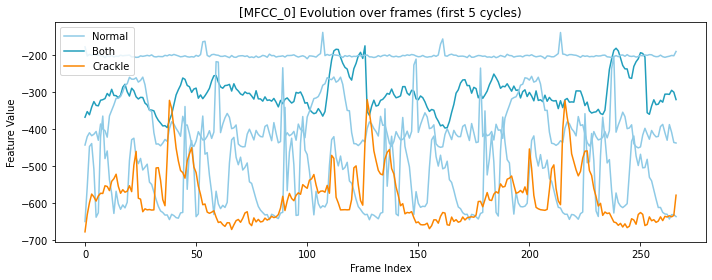

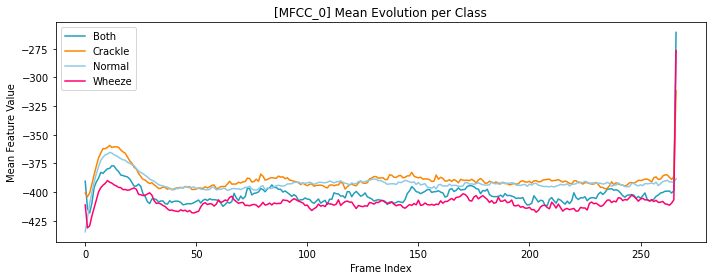

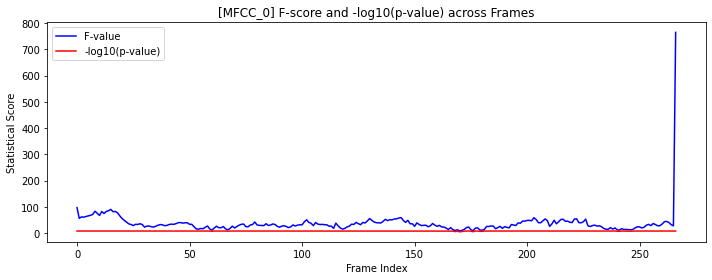

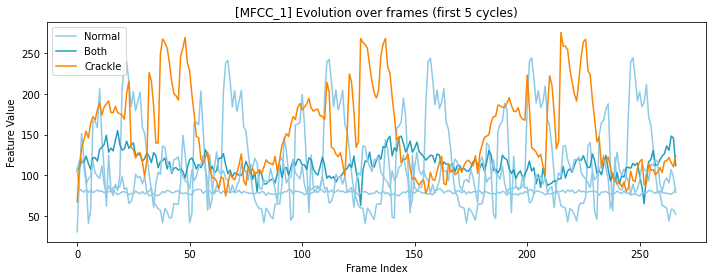

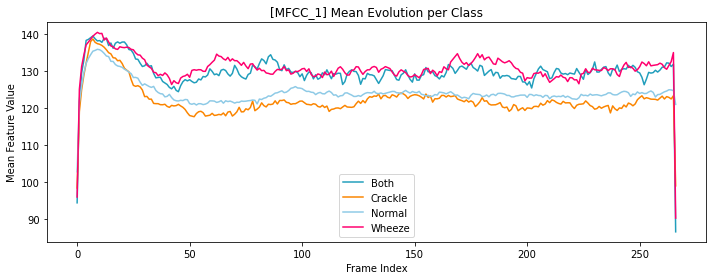

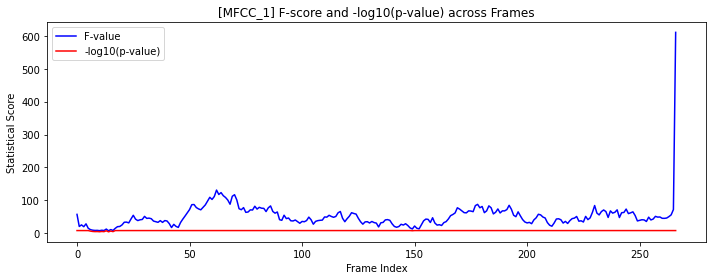

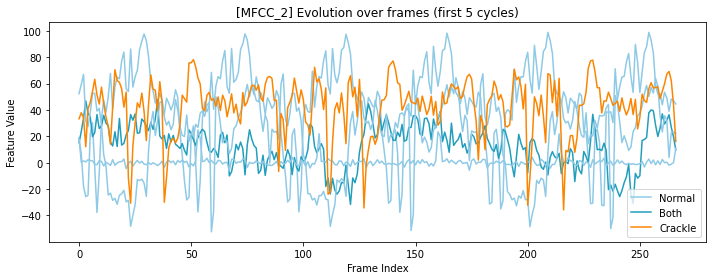

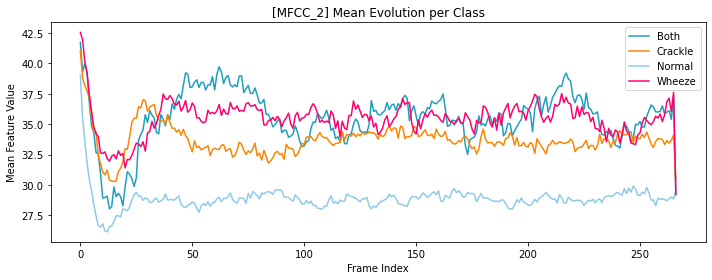

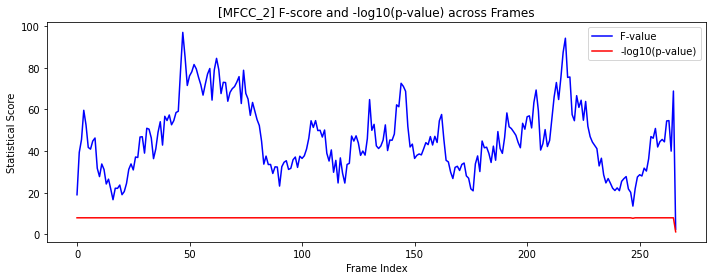

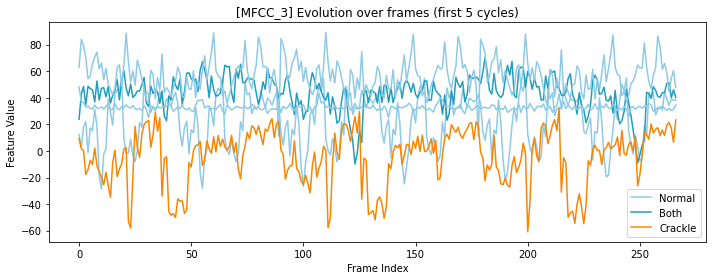

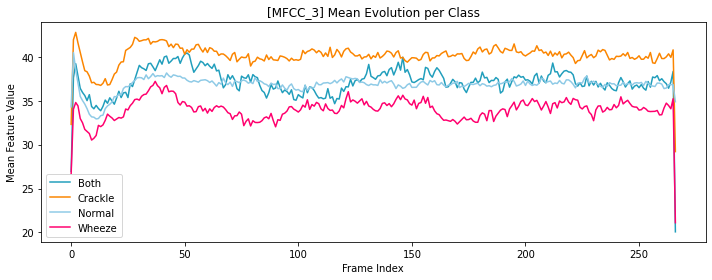

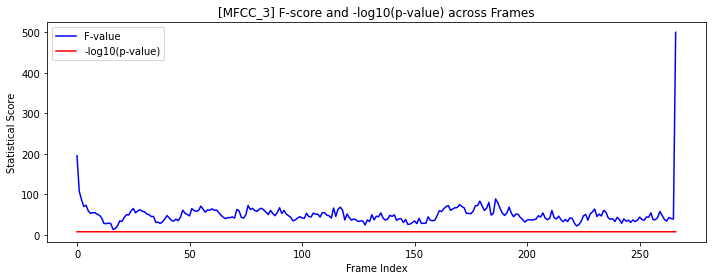

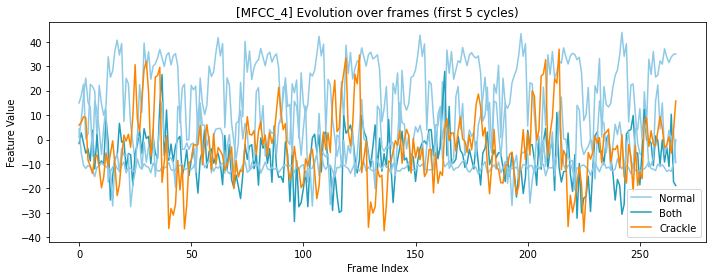

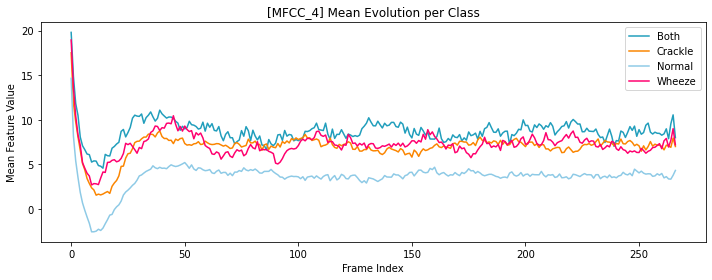

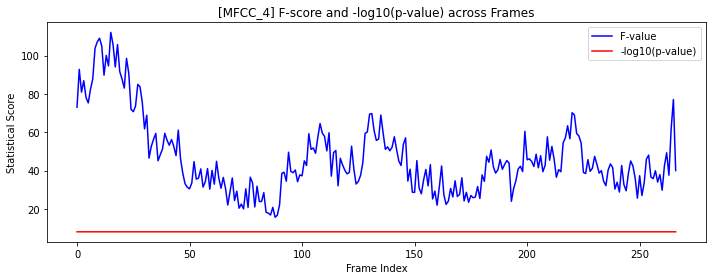

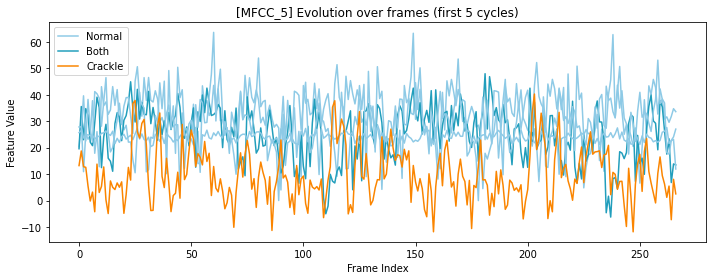

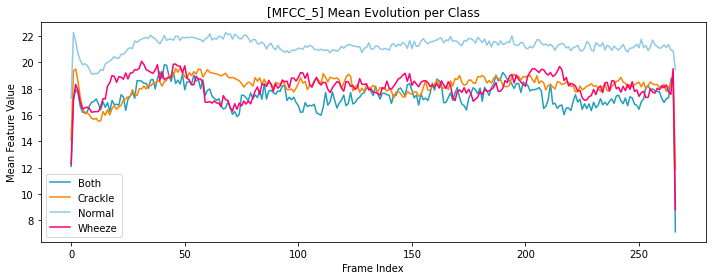

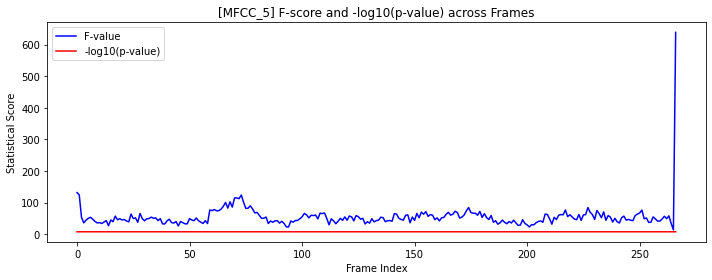

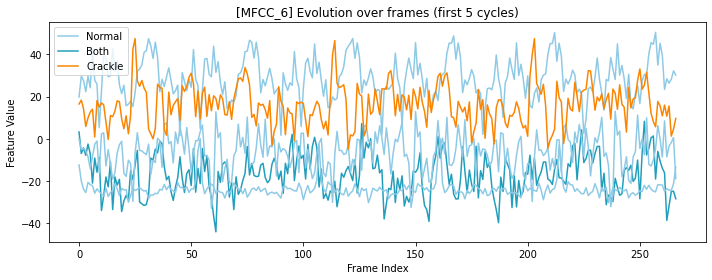

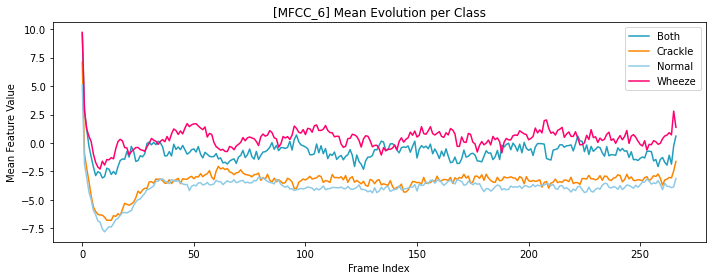

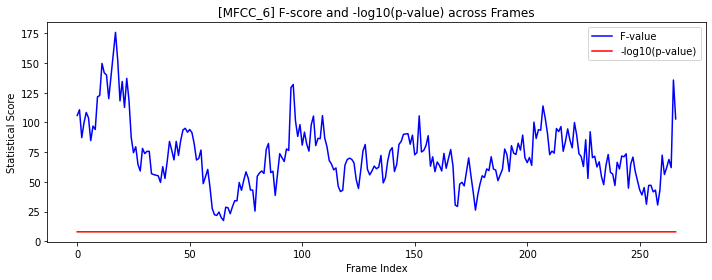

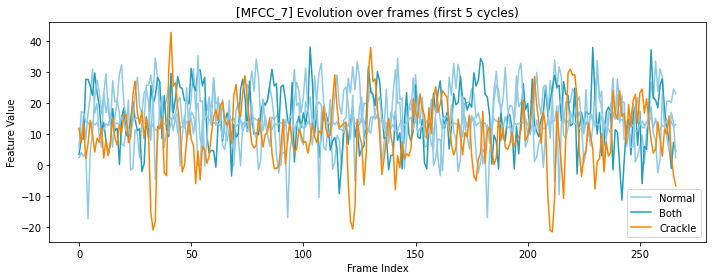

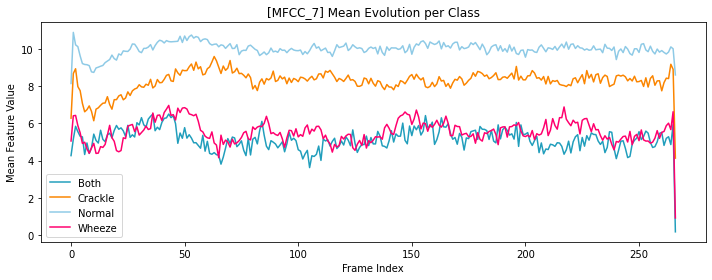

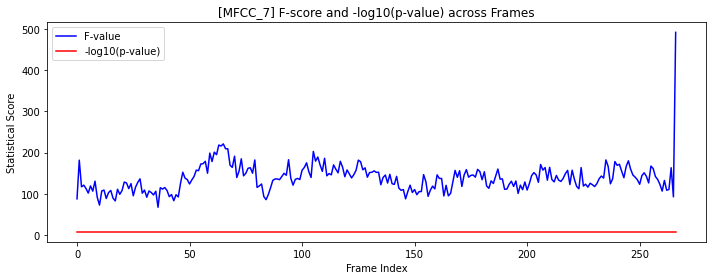

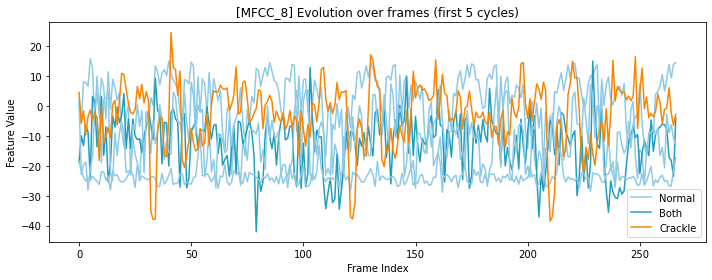

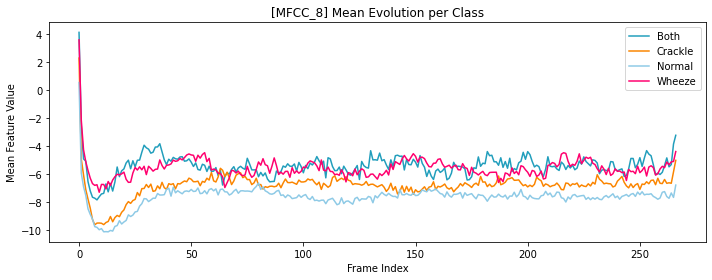

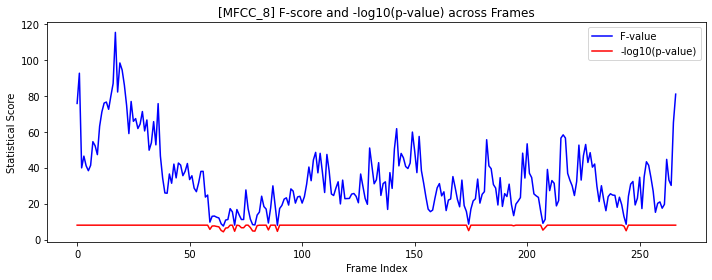

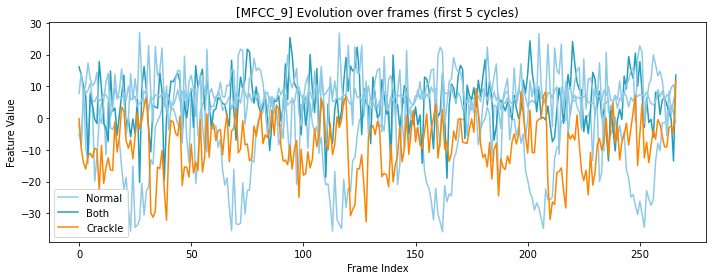

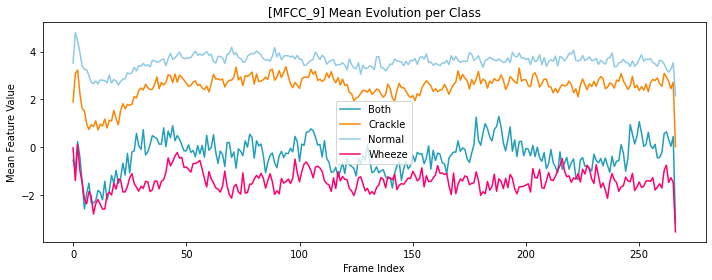

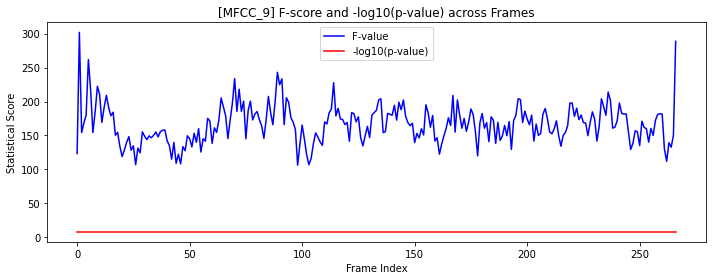

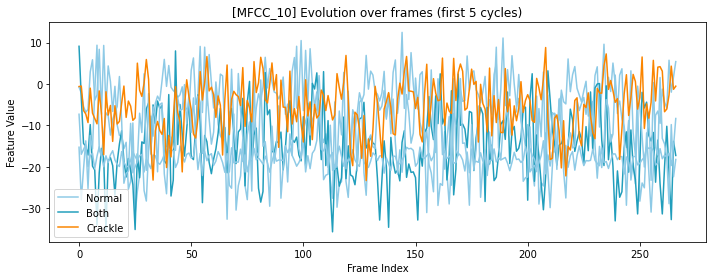

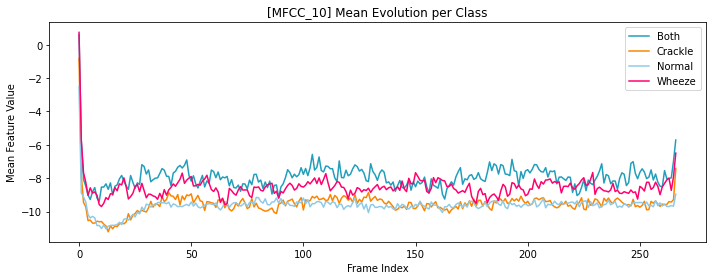

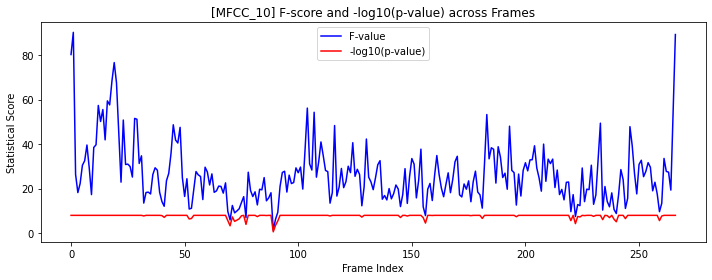

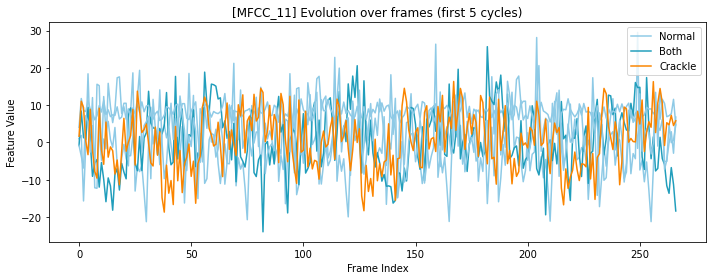

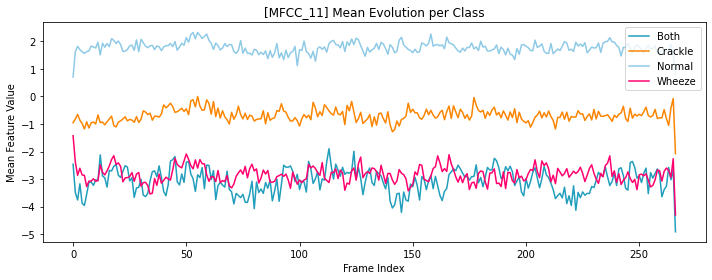

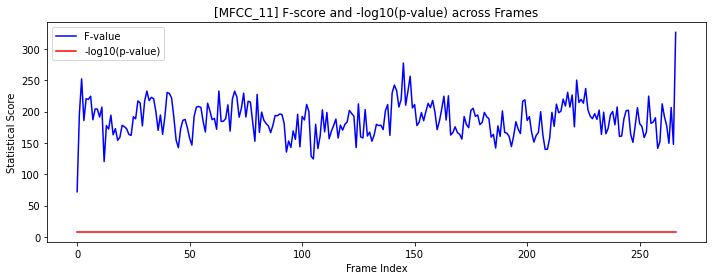

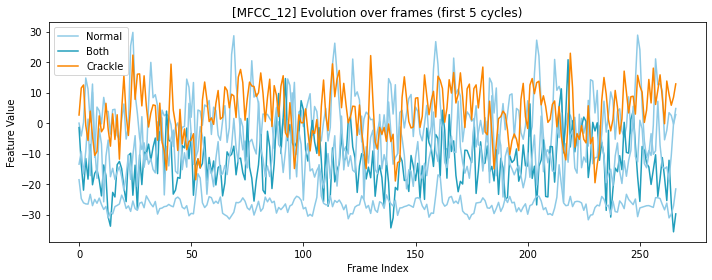

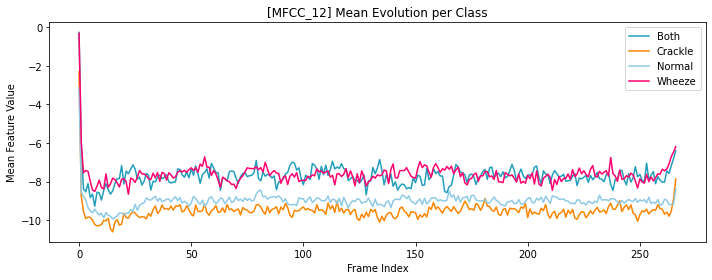

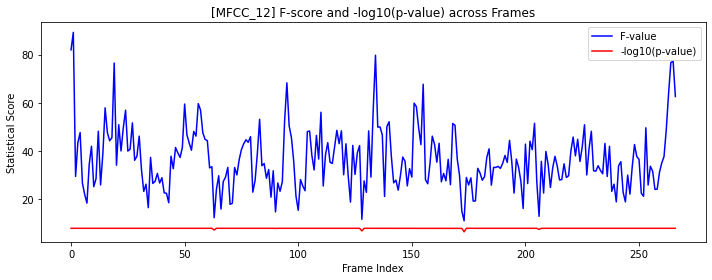

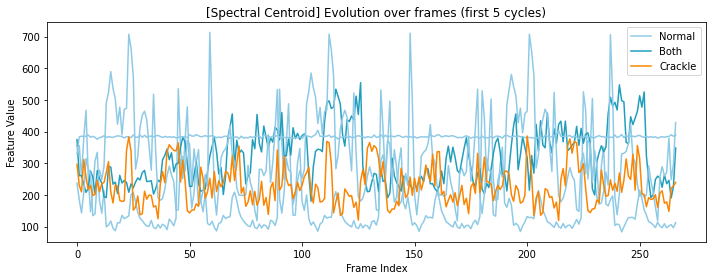

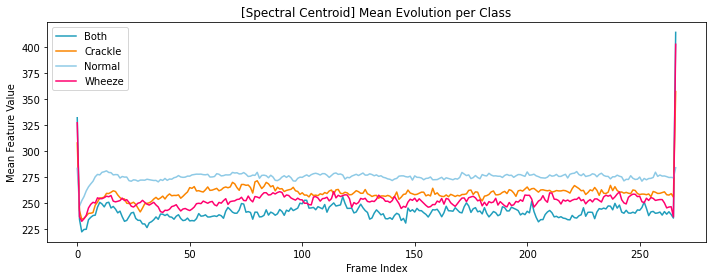

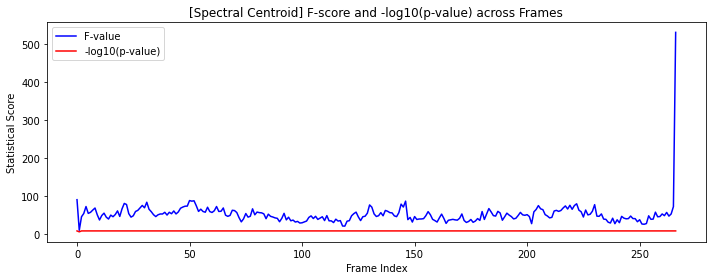

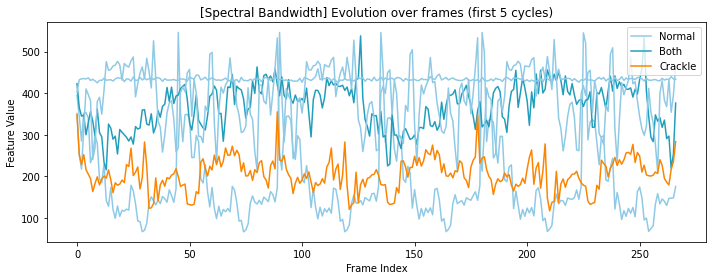

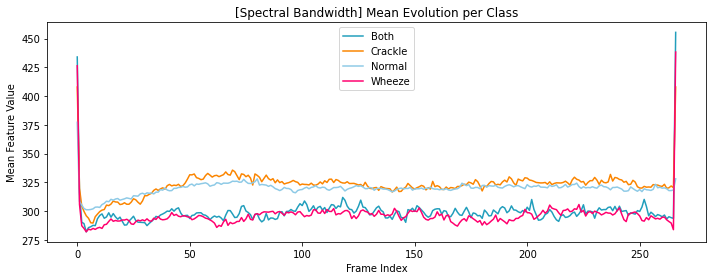

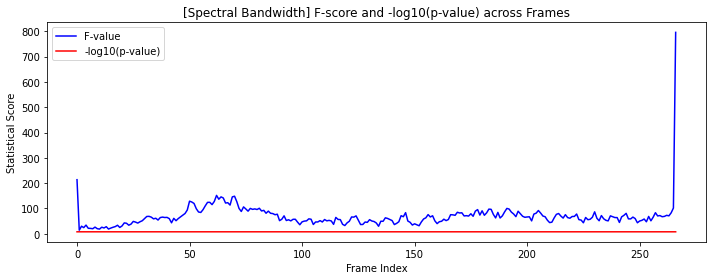

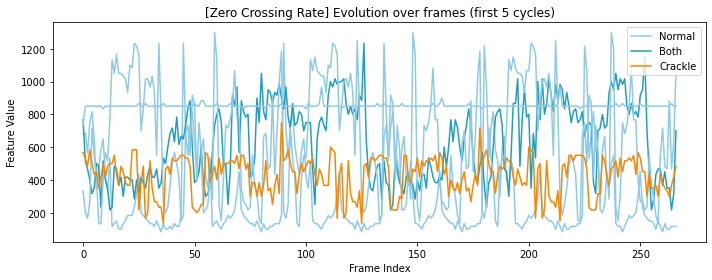

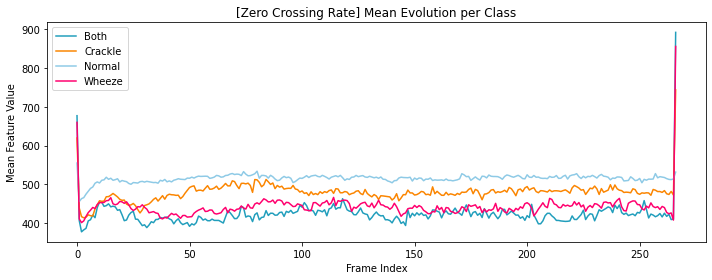

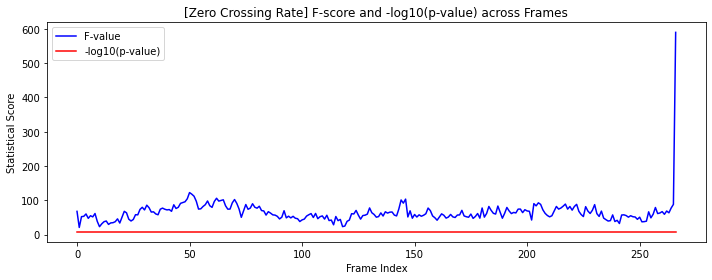

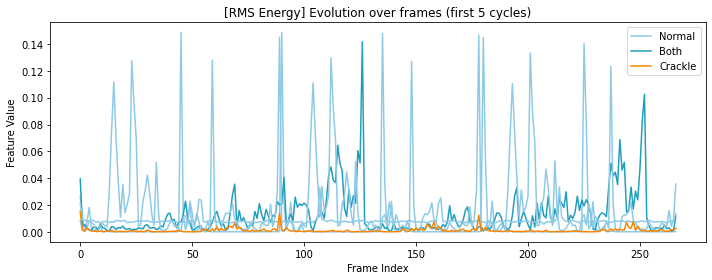

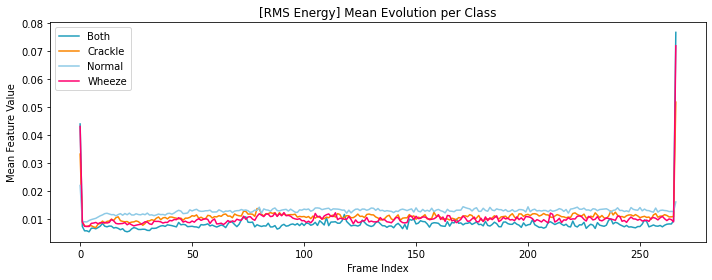

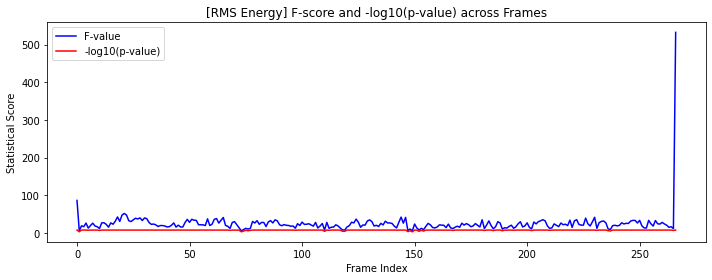

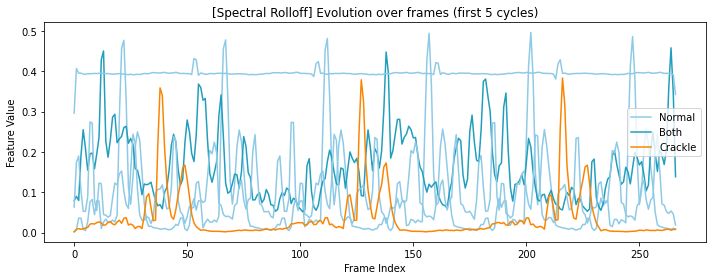

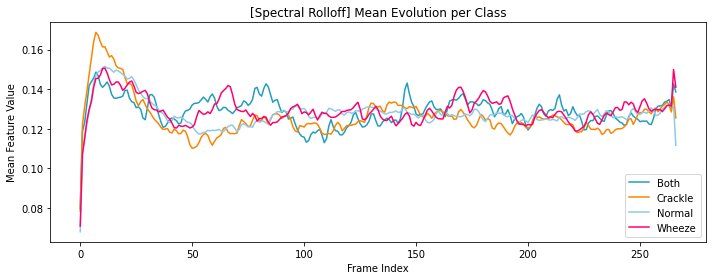

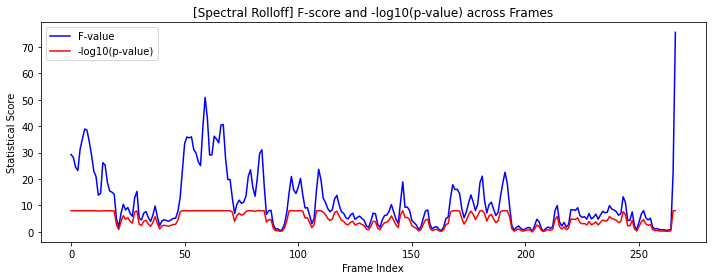

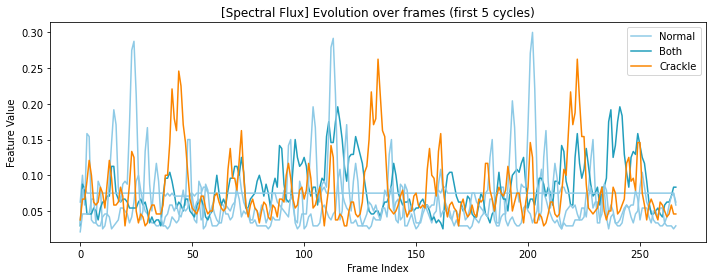

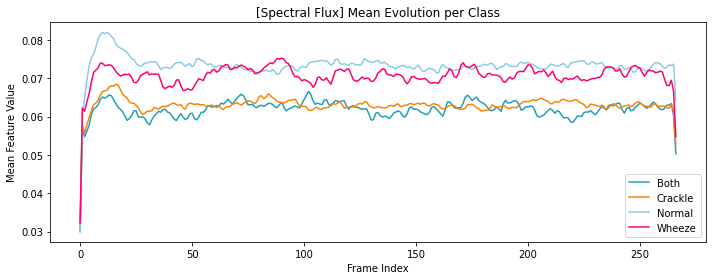

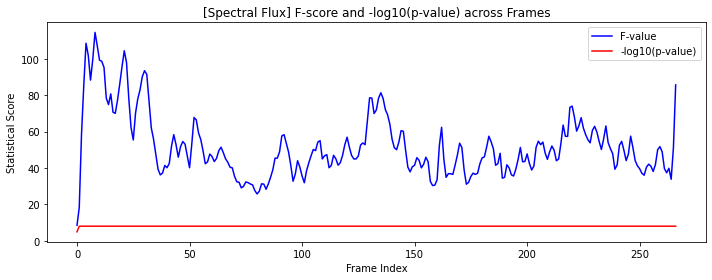

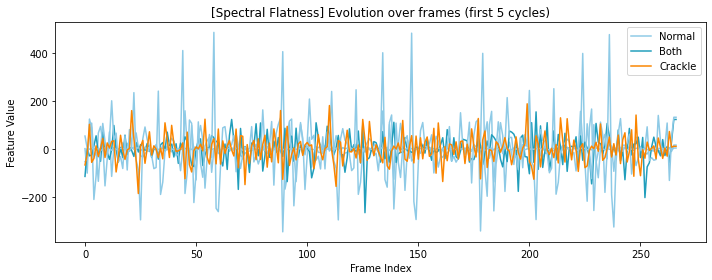

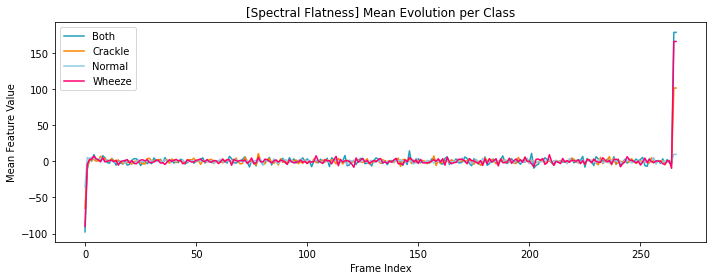

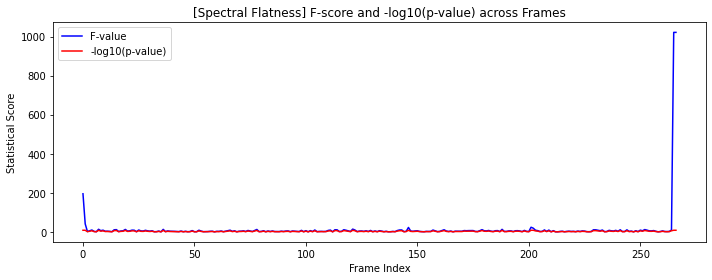

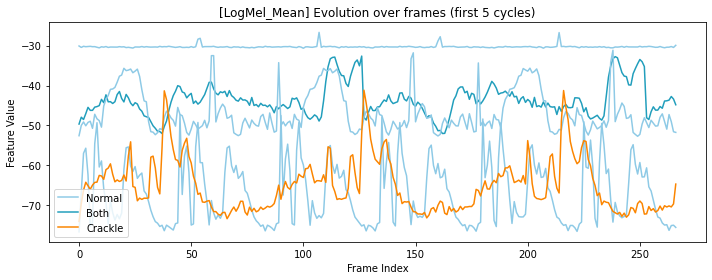

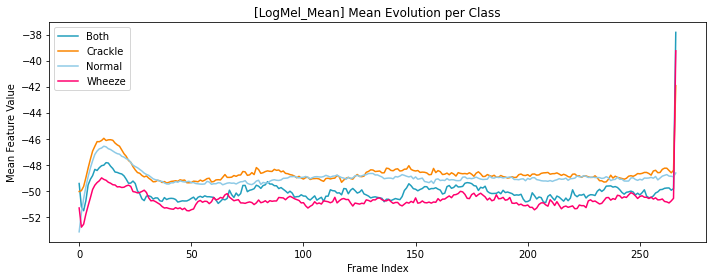

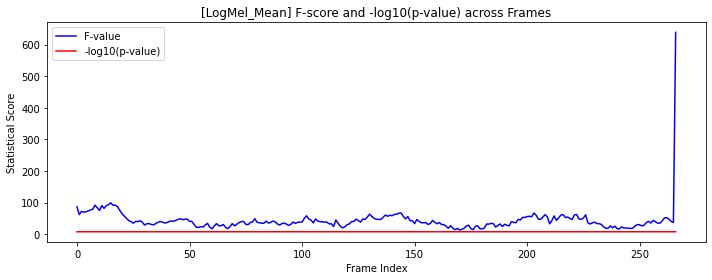

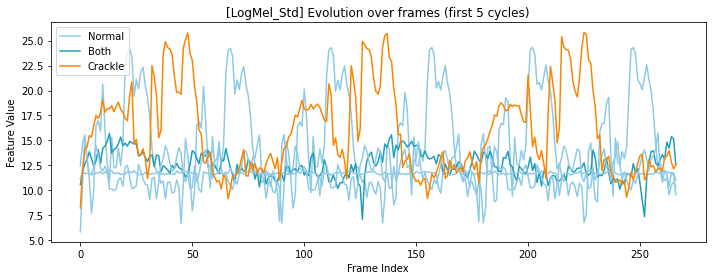

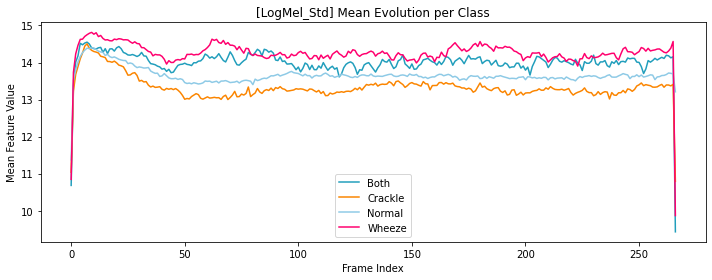

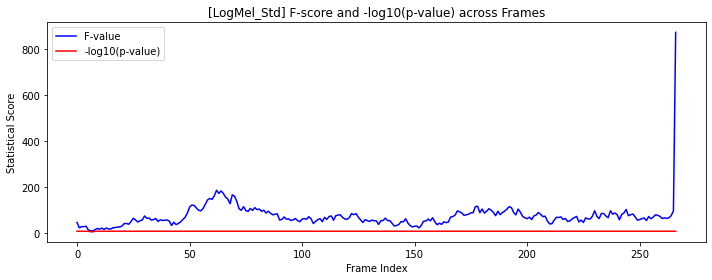

In [11]:
from utils.visuals import plot_feature_diagnostics

# Load the training set data
training_features = np.load(os.path.join(TRAINING_SET_FOLDER, "training_features.npy"))
training_labels = np.load(os.path.join(TRAINING_SET_FOLDER, "training_labels.npy"))

plot_feature_diagnostics(training_features, training_labels, FEATURE_NAMES, N_FRAMES, N_FEATURES, n_cycles_to_plot=5)

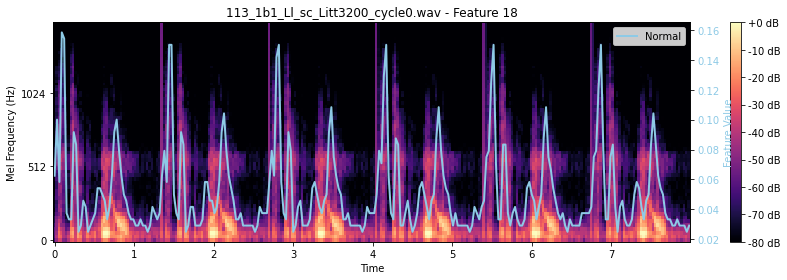

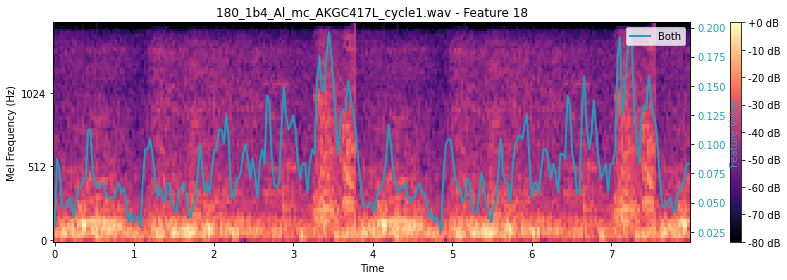

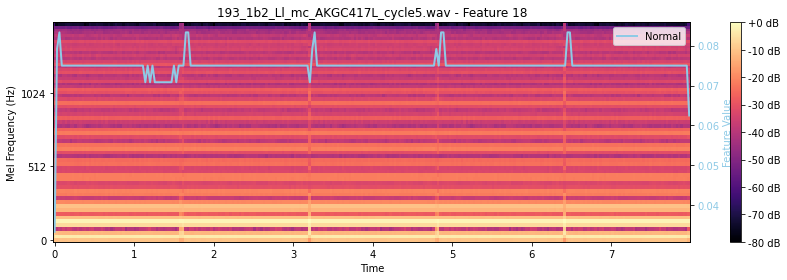

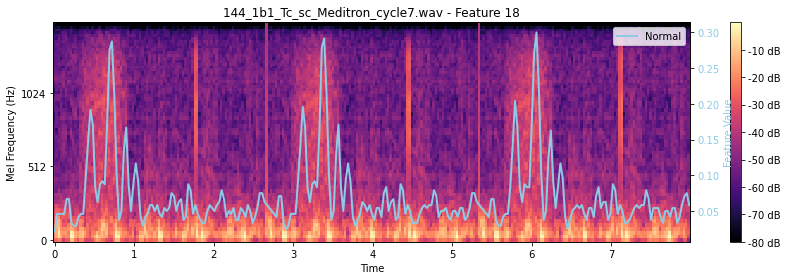

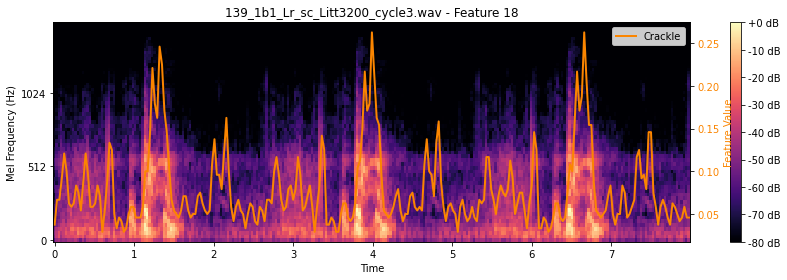

In [18]:
from utils.visuals import plot_feature_on_spectrogram

training_filenames = np.load(os.path.join(TRAINING_SET_FOLDER, "training_filenames.npy"))

# Overlay for example ZCR on the corresponding spectrogram for the first 5 cycles of training set
for i in range(5):
    plot_feature_on_spectrogram(
        fname=training_filenames[i],
        feature_vector=training_features[i],
        label=training_labels[i],
        feature_index=18,  # ZCR
        num_features=N_FEATURES,
        sampling_rate=SAMPLING_RATE,
        frame_length=FRAME_LENGTH,  
        hop_length=HOP_SIZE,
        n_mels=N_MELS
    )

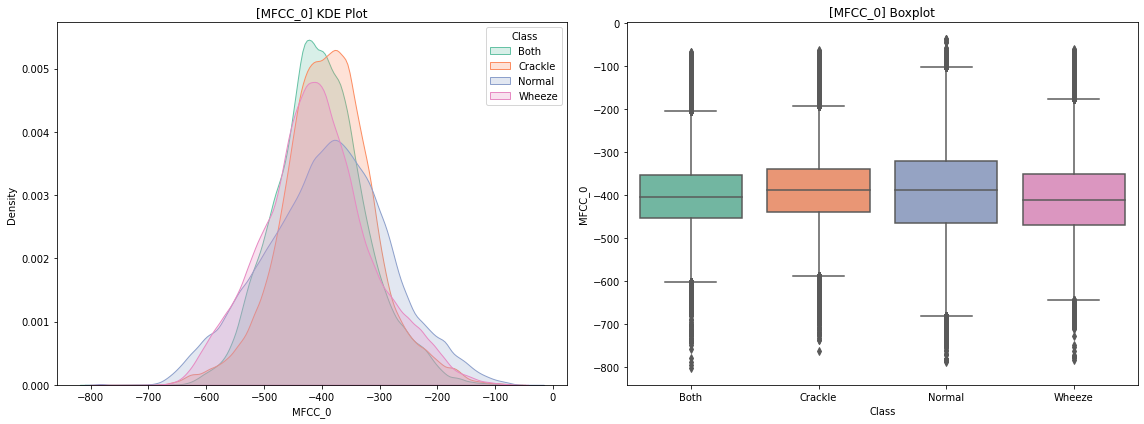

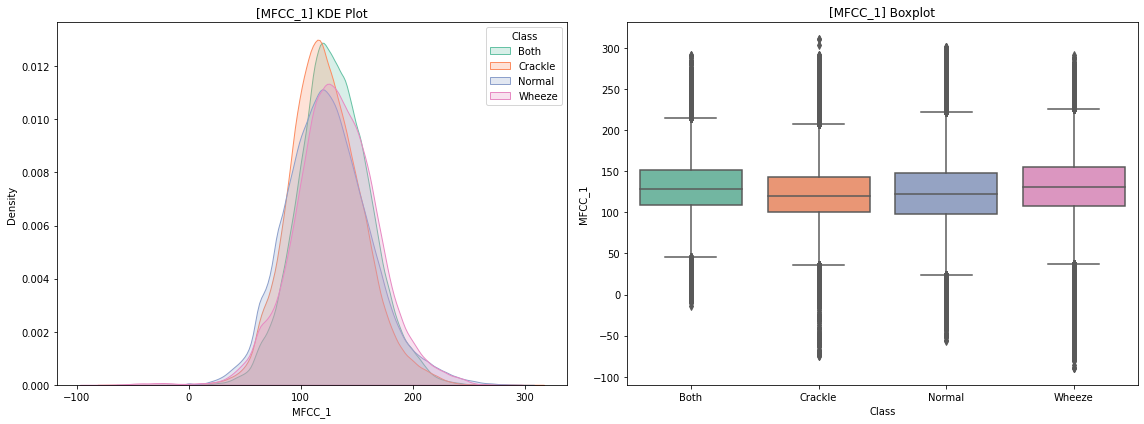

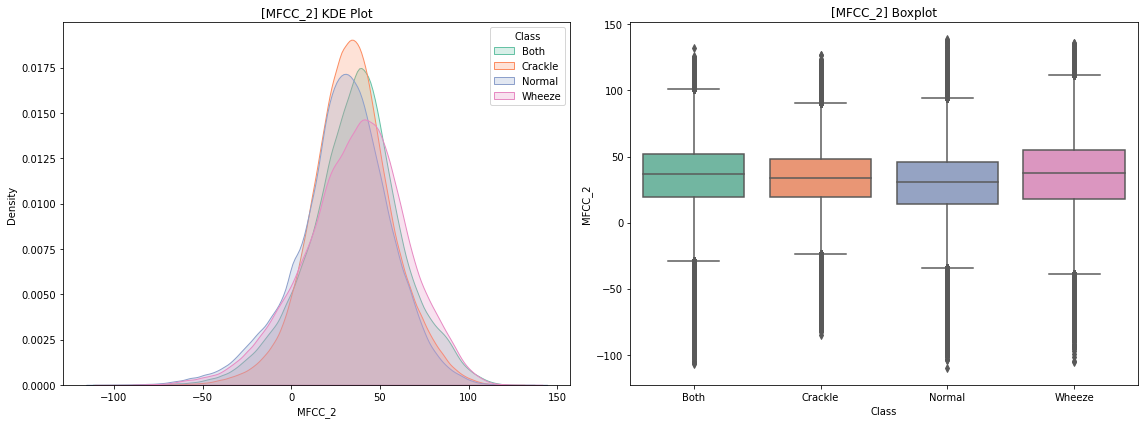

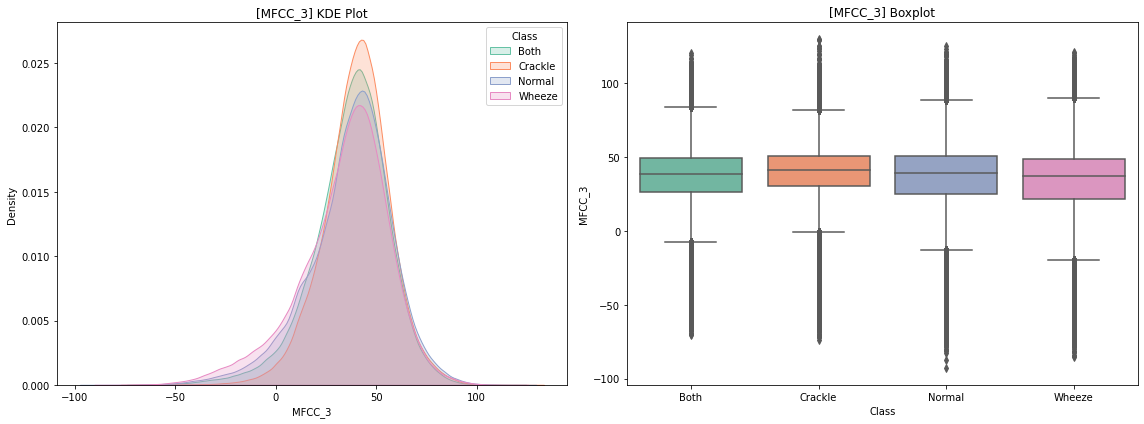

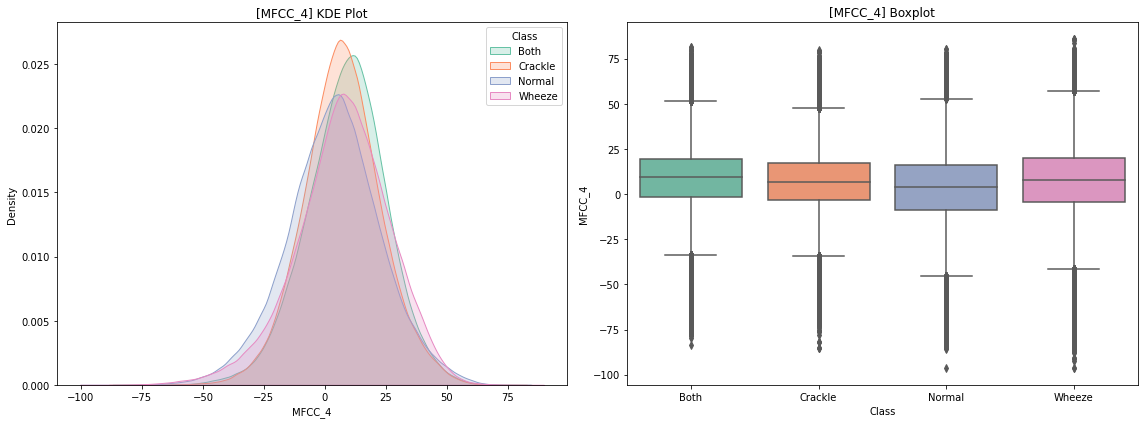

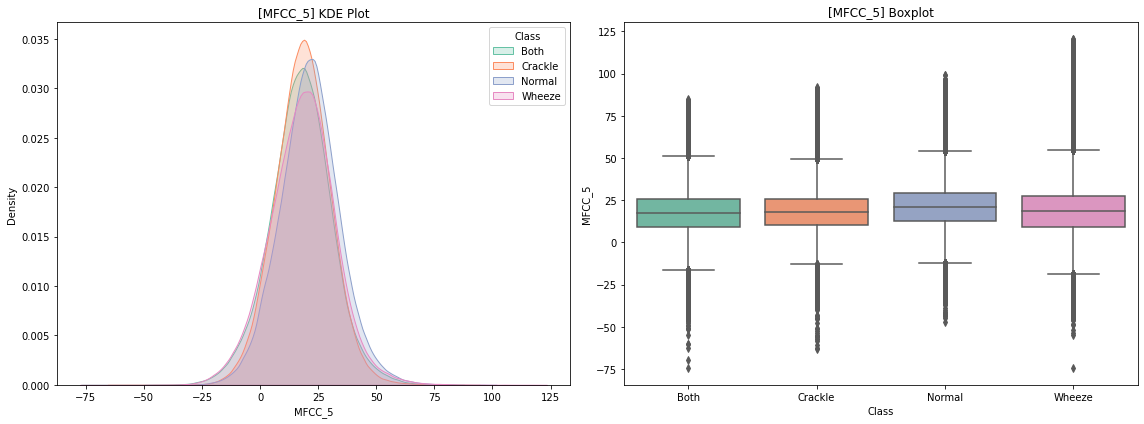

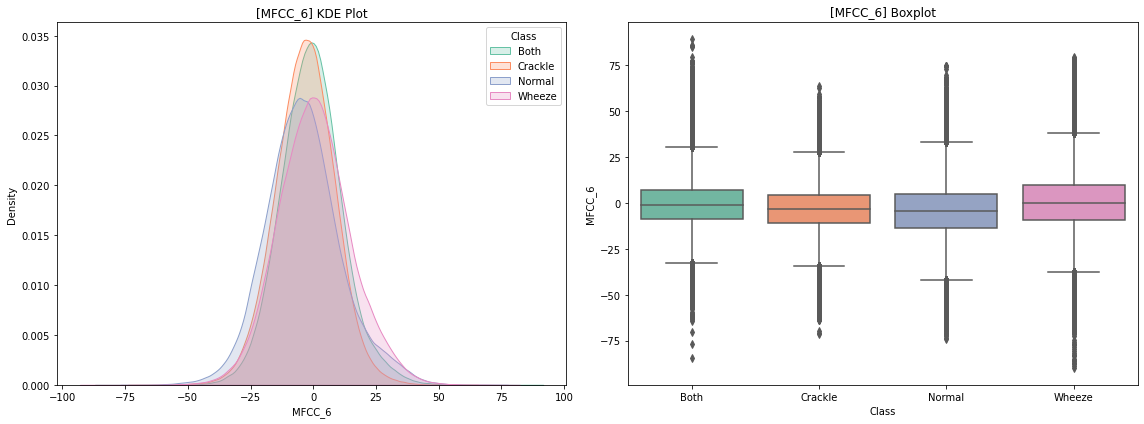

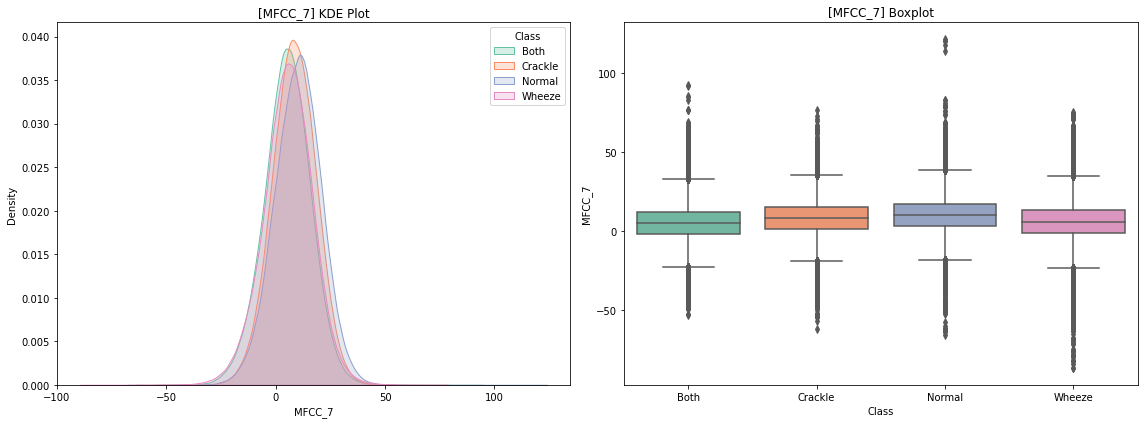

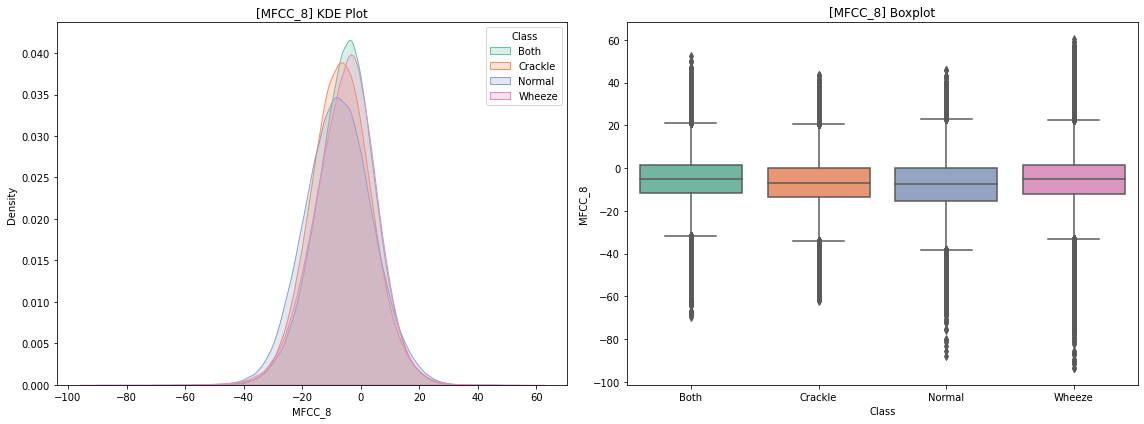

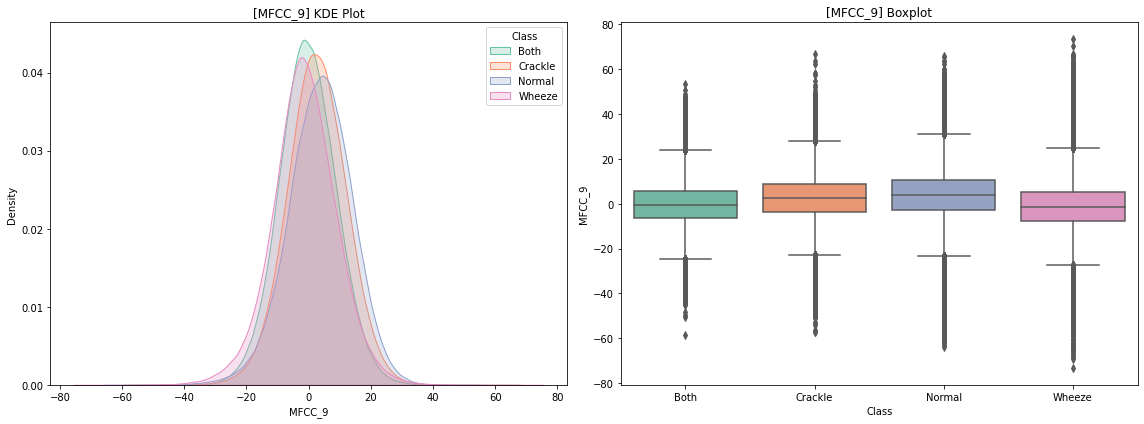

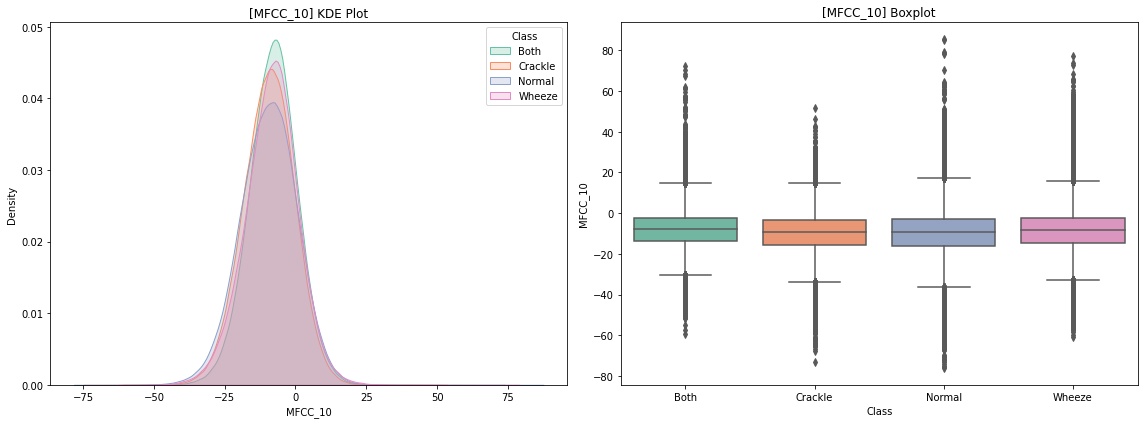

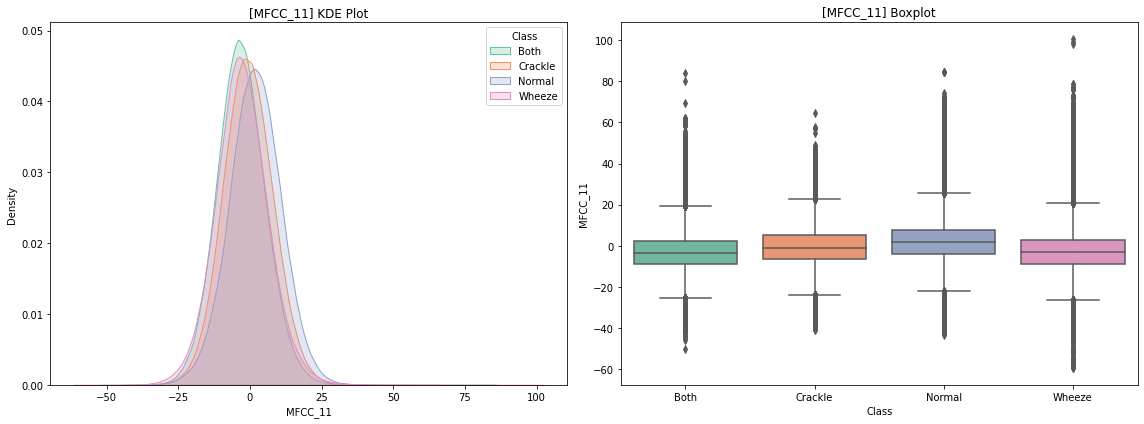

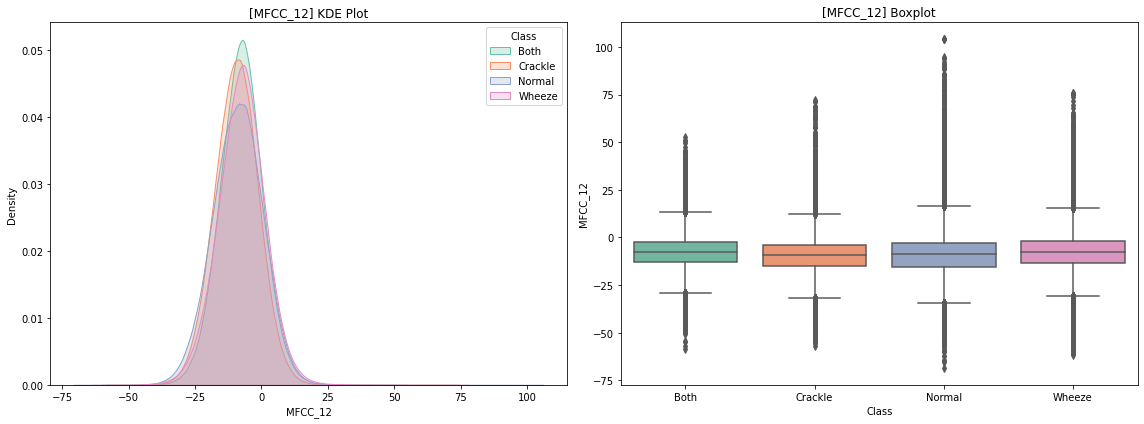

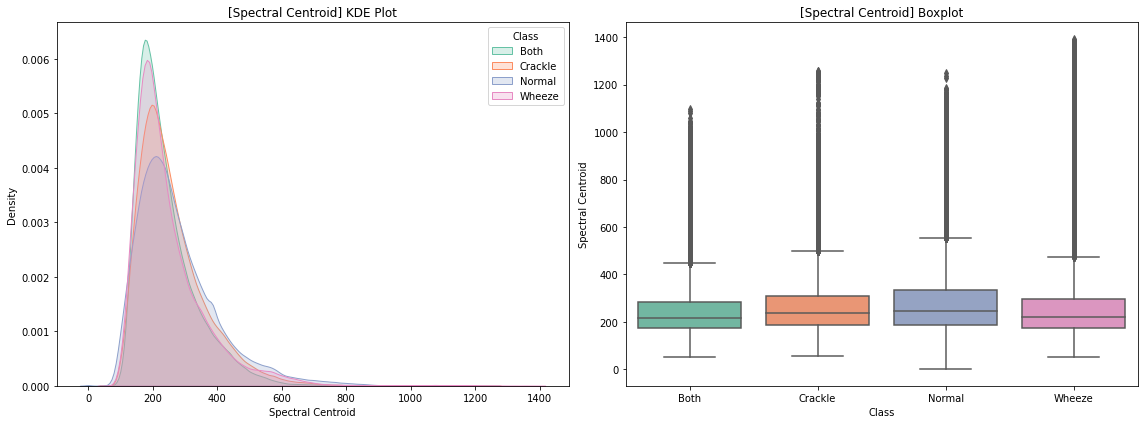

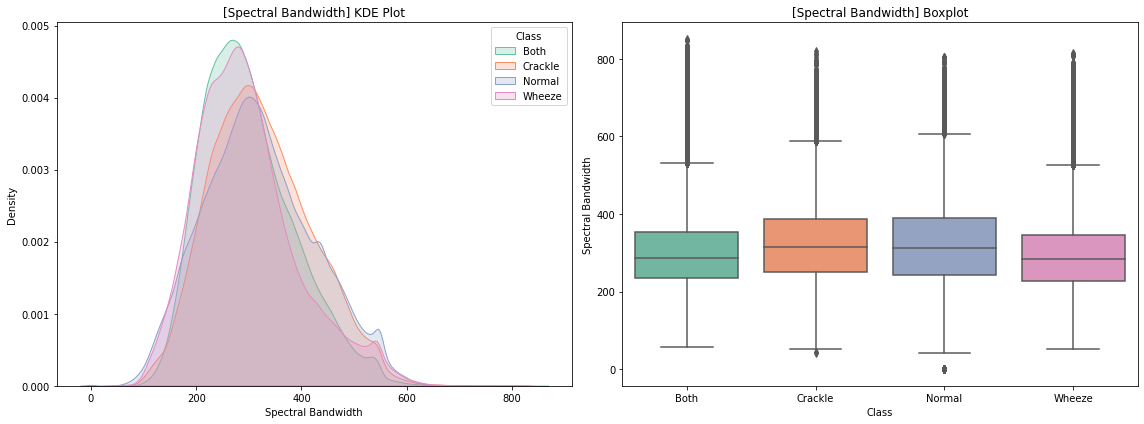

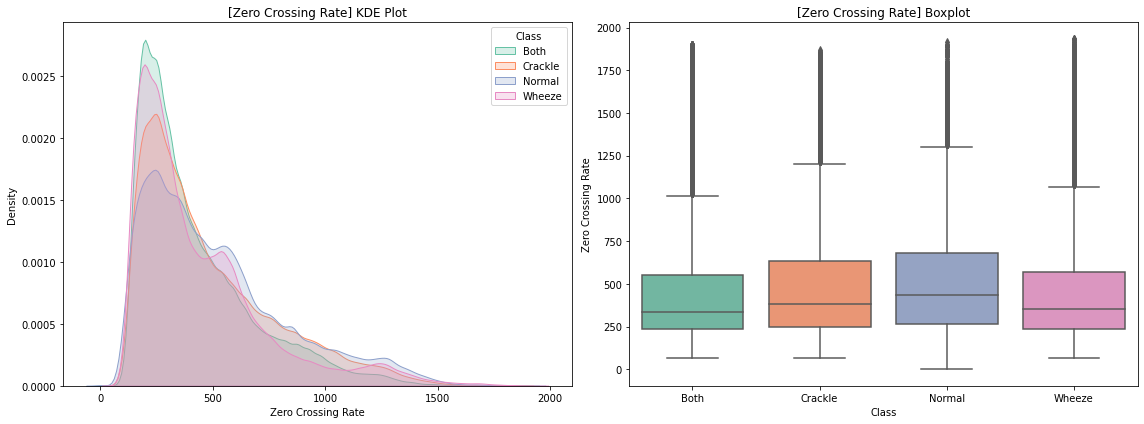

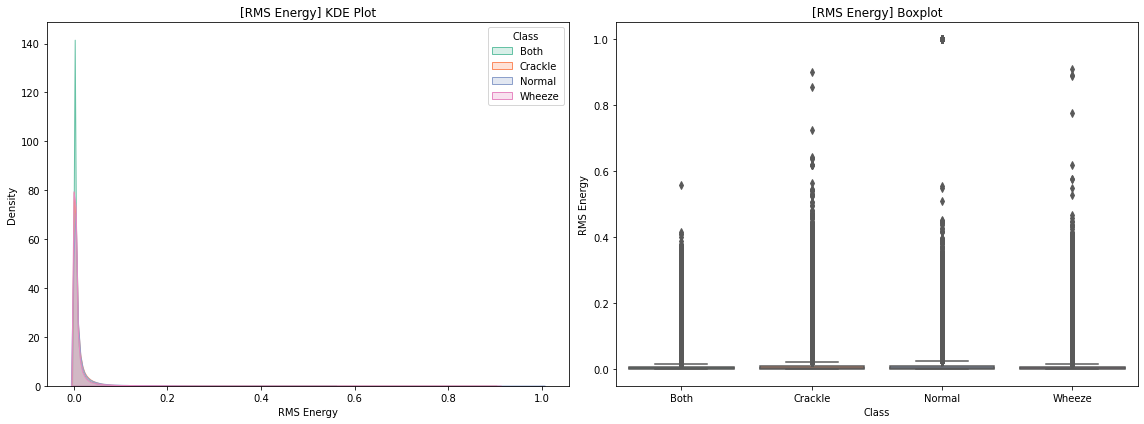

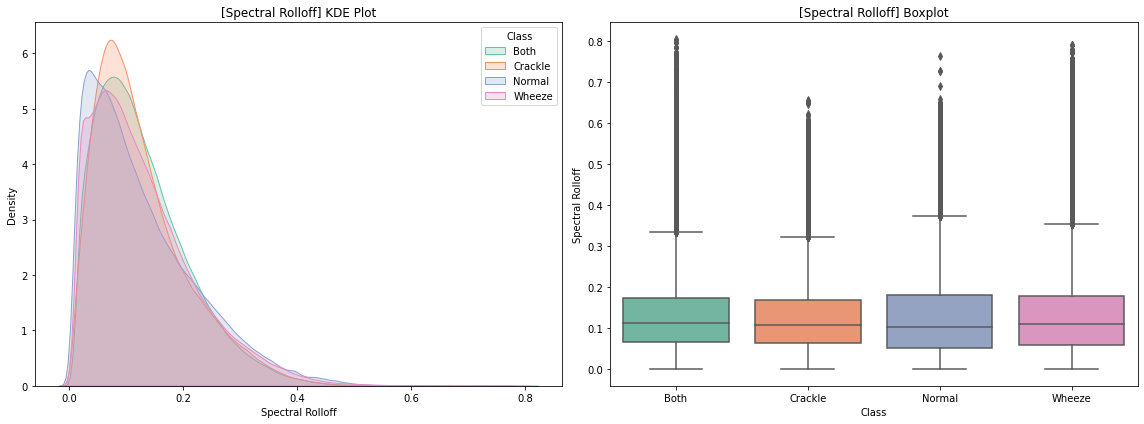

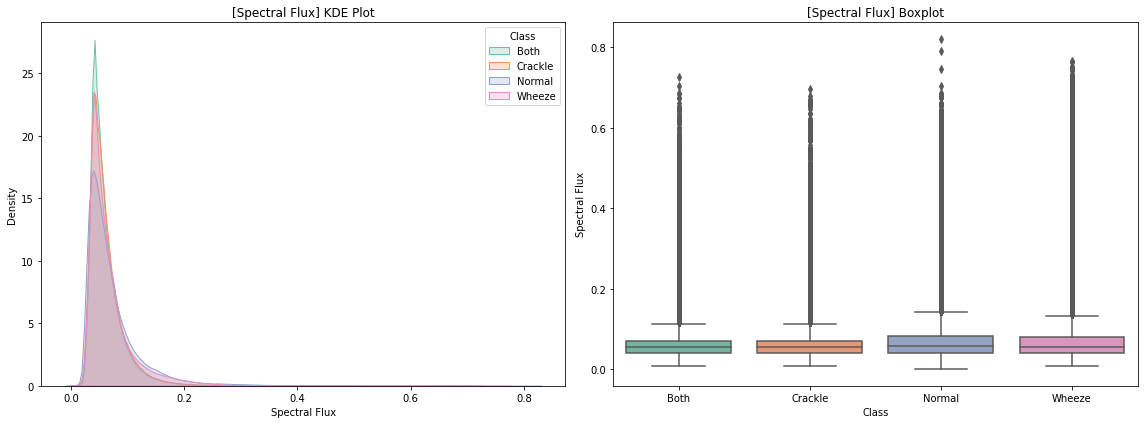

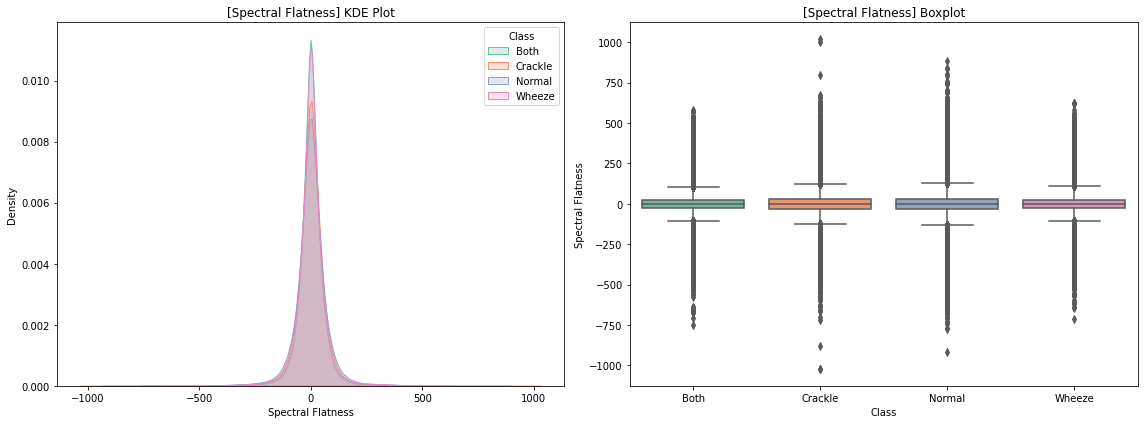

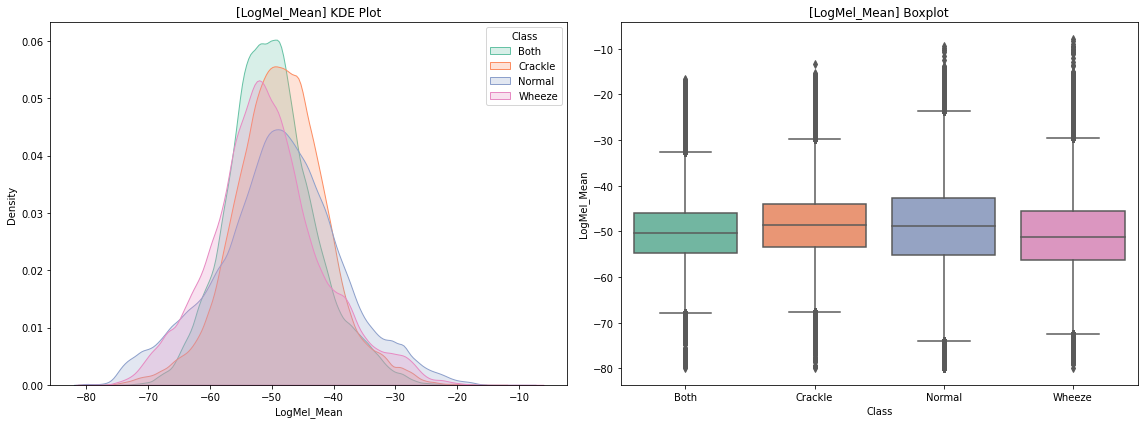

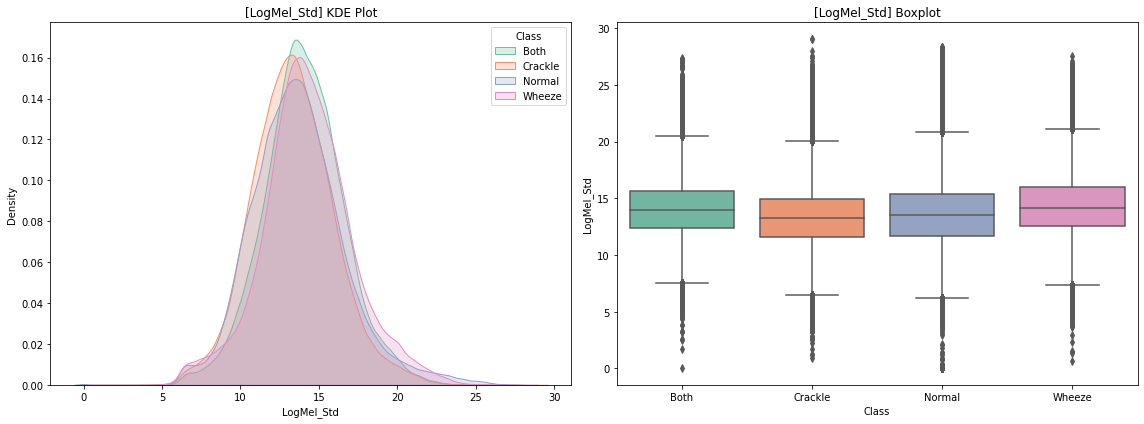

In [19]:
from utils.visuals import plot_feature_distributions

plot_feature_distributions(
    features=training_features,          
    labels=training_labels,             
    feature_names=FEATURE_NAMES,
    num_frames=N_FRAMES,
    label_palette="Set2"
)

Finally, we apply **PCA / t-SNE** in 2D and 3D on the training set to determine visually whether the extracted features can help discriminate naturally the abnormal sounds into separate clusters. We also **calculate the contribution of each feature** in order to select only those features that contribute the most.

1. Keep all the extracted features

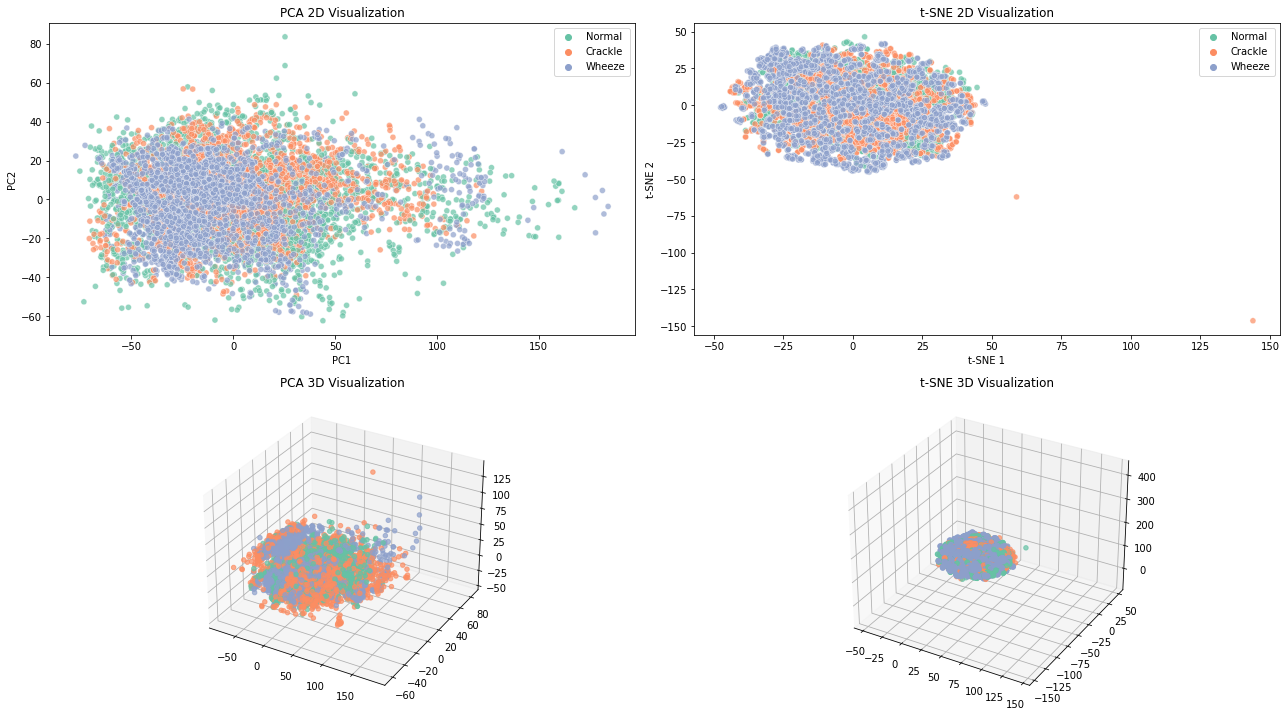

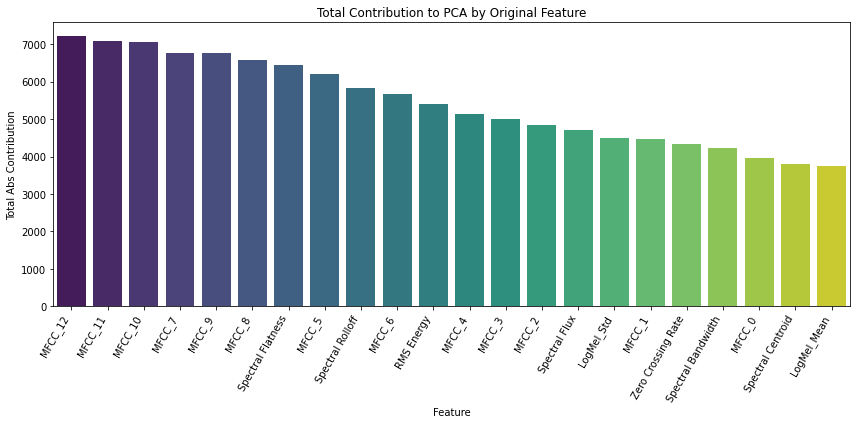

In [21]:
from utils.visuals import perform_pca_and_tsne

# Keep only Normal, Crackle and Wheeze cycles
mask = np.isin(training_labels, ["Normal", "Crackle", "Wheeze"])
X = training_features[mask]
y = training_labels[mask]

perform_pca_and_tsne(
    feature_matrix=X,
    labels=y,
    pca_components=0.95, # Keep 95% of variance
    tsne_components=3,
    perplexity=30,
    n_features=N_FEATURES,
    feature_names=FEATURE_NAMES
)

2. Keep only the selected features and choose the final features for the classification based on the PCA/t-SNE results

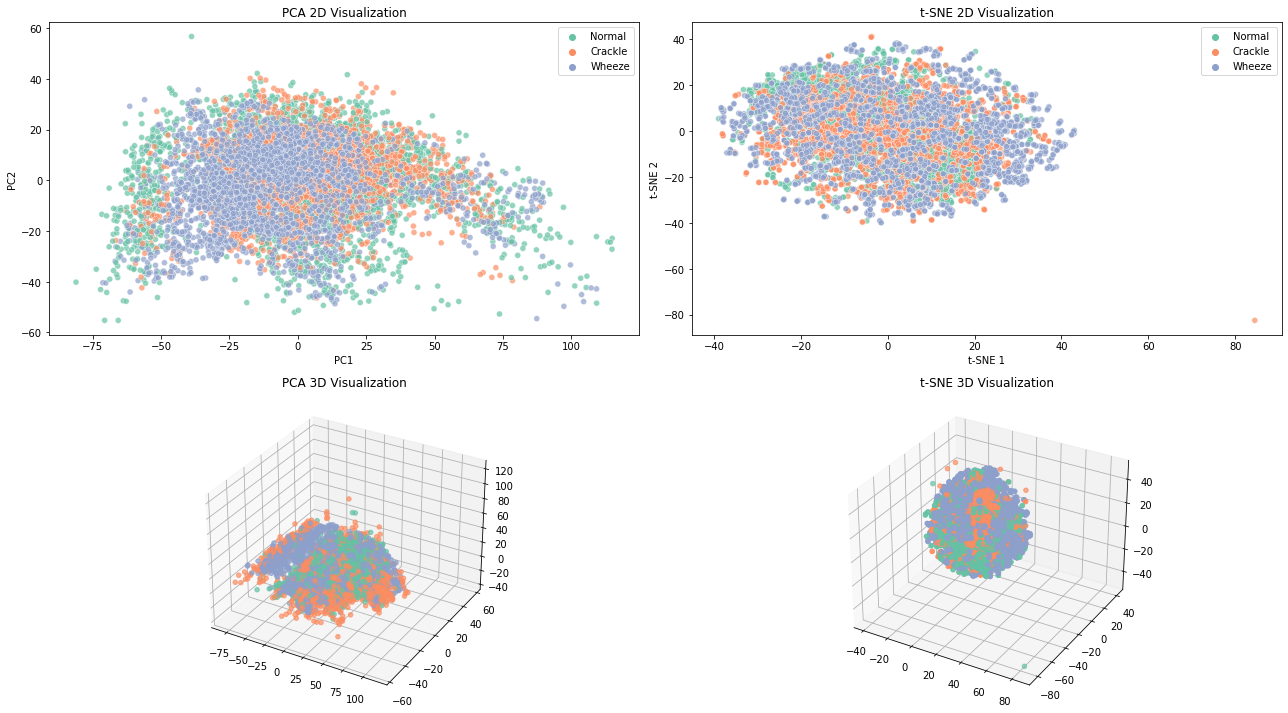

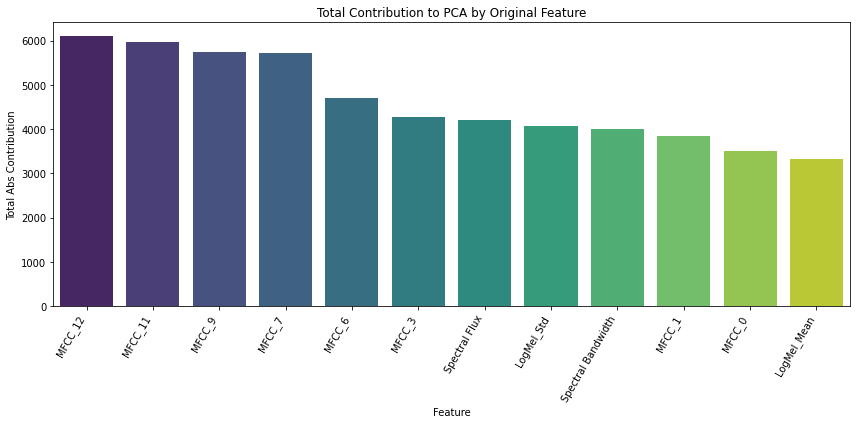

In [22]:
# Keep only Normal, Crackle and Wheeze cycles
mask = np.isin(training_labels, ["Normal", "Crackle", "Wheeze"])
X_full = training_features[mask]
y = training_labels[mask]

# Define the features we want to keep per frame (in frame-wise indexing for the array)
frame_indices_to_keep = [0, 1, 3, 6, 7, 9, 11, 12, 14, 18, 20, 21]
selected_indices = []
for f in range(N_FRAMES):
    base = f * N_FEATURES
    selected_indices.extend([base + i for i in frame_indices_to_keep])

X = X_full[:, selected_indices]

# Run PCA and t-SNE
perform_pca_and_tsne(
    feature_matrix=X,
    labels=y,
    pca_components=0.95, # Keep 95% of variance
    tsne_components=3,
    perplexity=30,
    n_features=len(frame_indices_to_keep),  # 12 selected features
    feature_names=[FEATURE_NAMES[i] for i in frame_indices_to_keep]
)

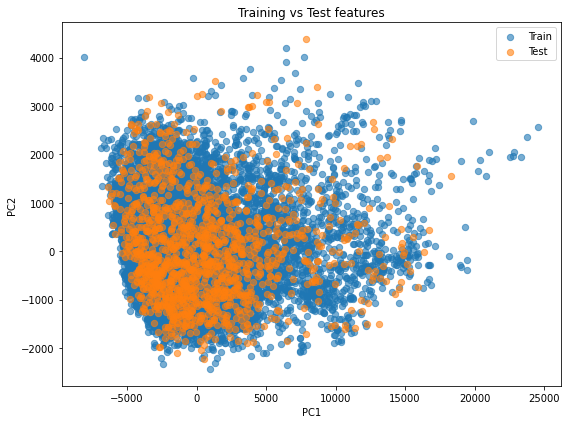

In [26]:
# Load test features
test_features = np.load(os.path.join(TEST_SET_FOLDER, "test_features.npy"))

# Combine both sets
X_combined = np.vstack([training_features, test_features])
sets = np.array(["Train"] * len(training_features) + ["Test"] * len(test_features))

# PCA: retain 95% of variance
pca = PCA(n_components=0.95)
X_pca_full = pca.fit_transform(X_combined)

# Keep first 2 principal components for visualization
X_pca_vis = X_pca_full[:, :2]

plt.figure(figsize=(8, 6))
for set_name in ["Train", "Test"]:
    idx = sets == set_name
    plt.scatter(X_pca_vis[idx, 0], X_pca_vis[idx, 1], label=set_name, alpha=0.6, s=40)
plt.title("Training vs Test features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

From the PCA plot we observe a significant overlap between the training and test sets in the projected feature space. This suggests that both sets share a similar underlying distribution after feature extraction. As a result,the classification models trained on this feature representation are less likely to suffer from distribution mismatch.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.ensemble import RandomForestClassifier


def plot_feature_contribution_curve(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    feature_names: list,
    n_features: int,
    step: int = 2
) -> None:
    """
    Iteratively remove least contributing features (based on PCA) and evaluate Random Forest performance by plotting the weighted f1 score for each combination of features.

    Args:
        X_train (np.ndarray): Training data (samples x flattened features).
        y_train (np.ndarray): Training labels.
        X_test (np.ndarray): Test data (samples x flattened features).
        y_test (np.ndarray): Test labels.
        feature_names (list): Names of features per frame.
        n_features (int): Number of distinct features per frame.
        step (int): How many features to remove at each iteration.

    Returns:
        None
    """
    n_total_features = X_train.shape[1]
    n_frames = n_total_features // n_features

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    pca = PCA(n_components=0.95)
    pca.fit(X_scaled)

    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    total_contribution = np.zeros(n_features)
    for feat_idx in range(n_features):
        indices = [f * n_features + feat_idx for f in range(n_frames)]
        total_contribution[feat_idx] = np.sum(np.abs(loadings[indices, :]))

    sorted_indices = np.argsort(total_contribution)[::-1]
    ordered_features = np.array(feature_names)[sorted_indices]

    results = []

    for k in range(n_features, 4, -step):
        selected_feats = ordered_features[:k]
        selected_feat_indices = [feature_names.index(f) for f in selected_feats]

        selected_columns = []
        for f in range(n_frames):
            for idx in selected_feat_indices:
                selected_columns.append(f * n_features + idx)

        X_train_sel = X_train[:, selected_columns]
        X_test_sel = X_test[:, selected_columns]

        clf = RandomForestClassifier(random_state=42)
        clf.fit(X_train_sel, y_train)
        y_pred = clf.predict(X_test_sel)
        f1 = f1_score(y_test, y_pred, average="weighted")
        results.append((k, f1))

    df_results = pd.DataFrame(results, columns=["Num_Features", "F1_Score"])

    # Plot graph
    plt.figure(figsize=(8, 5))
    plt.plot(df_results["Num_Features"], df_results["F1_Score"], marker='o', linestyle='-')
    plt.xlabel("Feature Vector Length")
    plt.ylabel("Weighted F1 Score")
    plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.show()

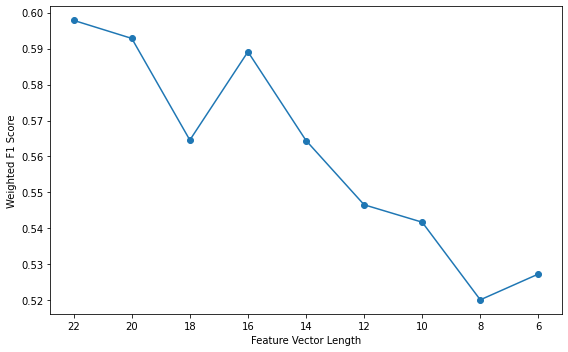

In [ ]:
# Load the training and test set data for the 3 classes
training_features = np.load(os.path.join(TRAINING_SET_FOLDER, "training_features_sc.npy"))
training_labels = np.load(os.path.join(TRAINING_SET_FOLDER, "training_labels_sc.npy"))
test_features = np.load(os.path.join(TEST_SET_FOLDER, "test_features_sc.npy"))
test_labels = np.load(os.path.join(TEST_SET_FOLDER, "test_labels_sc.npy"))

X_train = training_features[np.isin(training_labels, ["Normal", "Crackle", "Wheeze"])]
y_train = training_labels[np.isin(training_labels, ["Normal", "Crackle", "Wheeze"])]
X_test = test_features[np.isin(test_labels, ["Normal", "Crackle", "Wheeze"])]
y_test = test_labels[np.isin(test_labels, ["Normal", "Crackle", "Wheeze"])]

plot_feature_contribution_curve(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=FEATURE_NAMES,
    n_features=len(FEATURE_NAMES),
    step=2
)